# **ANALISIS PREDICTIVO DEL TIEMPO DE TRÁNSITO DE LOS BUQUES EN EL CANAL**


El objetivo central de este proyecto es desarrollar un modelo capaz de predecir con precisión el tiempo de tránsito de los buques, permitiendo una optimización proactiva de la logística interoceánica.

Para lograrlo, el Notebook consolida un ecosistema de datos multidimensional que incluye:



*  El registro histórico de tránsitos y tiempos de espera (**transit.parquet**).
*  La trazabilidad operativa en las esclusas (**locks_visit.parquet**).
*  Las características técnicas y estructurales de las embarcaciones (**specs.parquet**).
*   Un conjunto de variables meteorológicas críticas (**clima_total_2015_2024**).

Al cruzar estos datasets, buscamos identificar cómo factores como el tipo de buque, su carga y las condiciones de viento y presión afectan la fluidez del paso, transformando datos históricos en una herramienta de inteligencia predictiva para la toma de decisiones.

## **EXTRACCIÓN & LIMPIEZA DE DATOS**

Lo primero que haremos es poder extraer y convertir los datos de cada uno de los archivos en formato parquet a dataframes funcionales.

### **Transformación de los archivos de formato parquet a dataframes**

In [ ]:
import pandas as pd
import os

# Definimos los archivos que se leeran
specific_files = ['locks_visit.parquet', 'specs.parquet', 'transit.parquet']

# Inicializa un diccionario para almacenar los dataframes
dataframes = {}

# Lee cada archivo específico en un DataFrame
for fname in specific_files:
    file_path = os.path.join('/content/', fname)
    df = None

    try:
        # Intenta leer el archivo como Parquet
        df = pd.read_parquet(file_path)
        print(f"Archivo: {fname} leído como Parquet.")
    except Exception as e:
        print(f"Error al leer {fname} como Parquet: {e}")

    if df is not None:
        # Almacena el DataFrame en el diccionario
        dataframes[fname.replace('.parquet', '').replace('.csv', '')] = df

        # Muestra las primeras filas para confirmación
        display(df.head())

# Accedemos a los dataframes por sus nombres
locks_df = dataframes['locks_visit']
specs_df = dataframes['specs']
transit_df = dataframes['transit']

Archivo: locks_visit.parquet leído como Parquet.


,imo,mmsi,dt_pos_utc,Name,segr
0,2051.0,374001000.0,2019-01-01 00:00:00,Miraflores Locks Original,0
1,9534810.0,370313000.0,2019-01-01 00:00:20,Cocoli Locks,0
2,9377248.0,636013816.0,2019-01-01 00:00:55,Miraflores Locks Original,0
3,9397858.0,477133300.0,2019-01-01 00:01:05,Pedro Miguel Locks Original,0
4,9279989.0,352983000.0,2019-01-01 00:06:12,Cocoli Locks,0


Archivo: specs.parquet leído como Parquet.


,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,1000021,68.500,1980,484,3716.0,Oil,Yacht
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing)
2,1001178,49.580,702,0,2700.0,Oil,Yacht
3,1002225,30.800,397,387,756.0,Oil,Yacht
4,1002342,38.625,489,0,1156.0,Oil,Yacht


Archivo: transit.parquet leído como Parquet.


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
0,9717292.0,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111
1,9581239.0,1,South,Bulk carrier,2019-01-01 00:39:05,2019-01-02 02:41:17,2018-12-31 00:11:14,2018-12-31 23:09:29,0,22.970833,26.036667
2,9758038.0,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000
3,9369095.0,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167
4,9683398.0,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833


### **Transformación del archivo de clima csv a dataframe**

In [ ]:
clima_df = pd.read_csv("/content/clima_total_2015_2024.csv")

### **Limpieza de Datos de los Dataframes**

#### **Limpieza de SPECS_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11793 entries, 0 to 11792
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11793 non-null  int64  
 1   LengthBetweenPerpendicularsLBP  11793 non-null  float64
 2   GrossTonnage                    11793 non-null  int64  
 3   Deadweight                      11793 non-null  int64  
 4   Powerkwmax                      11787 non-null  float64
 5   MainEngineType                  11789 non-null  object 
 6   ShiptypeLevel5                  11793 non-null  object 
dtypes: float64(2), int64(3), object(2)
memory usage: 645.1+ KB


In [ ]:
print('Tipos de datos:')
display(specs_df.dtypes)

Tipos de datos:


,0
imo,int64
LengthBetweenPerpendicularsLBP,float64
GrossTonnage,int64
Deadweight,int64
Powerkwmax,float64
MainEngineType,object
ShiptypeLevel5,object


In [ ]:
# Transformamos la variable imo a string debido a que es un codigo y no un número
specs_df["imo"] = specs_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna:')
display(specs_df.isnull().sum())

Valores nulos por columna:


,0
imo,0
LengthBetweenPerpendicularsLBP,0
GrossTonnage,0
Deadweight,0
Powerkwmax,6
MainEngineType,4
ShiptypeLevel5,0


Observamos los valores nulos en las columnas ***Powerkwmax*** y ***MainEngineType***. Vamos a trabjar en estrategías de imputación para ambos campos.

##### **Imputación de Valores para MainEngineType**

Para este caso, vamos a utilizar 2 estrategías de imputación:

*  Primero para cada valor de ShiptypeLevel5, calcularemos cuál es el MainEngineType más frecuente (la moda) dentro de ese tipo de buque y usaremos ese valor para rellenar solo los nulos de ese mismo grupo.

* Después, cualquier fila que siga nula (por ejemplo, porque en su grupo no había datos válidos para calcular moda) se eliminara.

In [ ]:
# Imputar valores nulos en MainEngineType con la moda por ShiptypeLevel5
def imputar_moda_engine_type(df):
    df = df.copy()
    for shiptype in df['ShiptypeLevel5'].unique():
        mask = (df['ShiptypeLevel5'] == shiptype)
        moda = df.loc[mask, 'MainEngineType'].mode(dropna=True)
        if not moda.empty:
            df.loc[mask & df['MainEngineType'].isnull(), 'MainEngineType'] = moda[0]
    return df

specs_df = imputar_moda_engine_type(specs_df)

# Eliminar registros que aún tengan MainEngineType nulo después de la imputación
specs_df = specs_df[~specs_df['MainEngineType'].isnull()].reset_index(drop=True)

# Verificar que ya no hay nulos en MainEngineType
display(specs_df['MainEngineType'].isnull().sum())

np.int64(0)

##### **Imputación de Valores para Powerkwmax**

En este caso, vamos a busca la media del grupo más específico (MainEngineType + ShiptypeLevel5) y, si no existe suficiente dato en ese cruce, cae a una media más general solo por ShiptypeLevel5

In [ ]:
# Imputar valores nulos en Powerkwmax
import numpy as np

def imputar_media_powerkwmax(df):
    df = df.copy()
    mask_nulo = df['Powerkwmax'].isnull()
    for idx in df[mask_nulo].index:
        engine = df.at[idx, 'MainEngineType']
        shiptype = df.at[idx, 'ShiptypeLevel5']
        # Media por MainEngineType y ShiptypeLevel5
        media1 = df[(df['MainEngineType'] == engine) & (df['ShiptypeLevel5'] == shiptype)]['Powerkwmax'].mean()
        if not np.isnan(media1):
            df.at[idx, 'Powerkwmax'] = media1
        else:
            # Media por ShiptypeLevel5
            media2 = df[df['ShiptypeLevel5'] == shiptype]['Powerkwmax'].mean()
            if not np.isnan(media2):
                df.at[idx, 'Powerkwmax'] = media2
    return df

specs_df = imputar_media_powerkwmax(specs_df)

# Confirmar que no quedan nulos en Powerkwmax
display(specs_df['Powerkwmax'].isnull().sum())

np.int64(0)

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 644.9+ KB


##### **Creación de nueva variable de categorica para los distintos ShiptypeLevel5**

Vamos a crear una variable para  usa para homologar y simplificar la gran variedad de valores de ShiptypeLevel5 en categorías más simples (grupos) reduciendo la cardinalidad sin perder interpretabilidad. Además, el resultado permite comparar mejor frecuencias entre tipos de buque y trabajar con una variable categórica más ordenada y robusta.

In [ ]:
# Homologación en español sin usar "Other"
specs_df = specs_df.copy()

# Reglas explícitas por categoría (en español)
homologation_rules_es = [
    ("Tanquero", ["Tanker", "Crude", "Chemical", "LPG", "LNG", "Bunkering", "Bitumen", "Asphalt", "FSO", "FPSO", "Oil"]),
    ("Carga", ["Cargo", "Container", "Bulk", "Carrier", "Ro-Ro", "Refrigerated", "Cement", "Ore", "Deck"]),
    ("Pasajeros", ["Passenger", "Cruise", "Vehicles Carrier", "Rail Vehicles Carrier", "General Cargo/Passenger"]),
    ("Remolque y Offshore", ["Tug", "Supply", "Offshore", "Anchor Handling", "Platform", "Drilling", "Pipe Layer", "Diving", "Service Operation", "Construction Vessel", "Crew", "Well Stimulation Vessel"]),
    ("Pesquero", ["Fishing", "Fish", "Fishery", "Seal Catcher"]),
    ("Naval y Gobierno", ["Patrol", "Naval", "Hospital", "Research", "Training", "Icebreaker", "Pollution", "Buoy Tender", "Utility"]),
    ("Especializado", ["Dredger", "Crane", "Cable", "Yacht Carrier", "Heavy Load", "Power Station", "Gas Processing", "Nuclear Fuel", "Landing", "Commissioning", "Work/Repair", "Trans Shipment", "Hopper, Motor"]),
    ("Yate", ["Yacht", "Sailing"]),
]

def map_shiptype_to_group_es(value):
    if pd.isna(value):
        return "Sin dato"

    text = str(value).strip()

    # 2) Reglas por patrones
    text_upper = text.upper()
    for group, patterns in homologation_rules_es:
        if any(p.upper() in text_upper for p in patterns):
            return group

specs_df["ShiptypeLevel_group"] = specs_df["ShiptypeLevel5"].apply(map_shiptype_to_group_es)

print("\nFrecuencia por grupo homologado:")
display(specs_df["ShiptypeLevel_group"].value_counts(dropna=False))


Frecuencia por grupo homologado:


,count
ShiptypeLevel_group,
Carga,7529
Tanquero,3271
Remolque y Offshore,320
Yate,220
Pasajeros,161
Pesquero,145
Naval y Gobierno,75
Especializado,70


In [ ]:
specs_df

,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5,ShiptypeLevel_group
0,1000021,68.500,1980,484,3716.0,Oil,Yacht,Yate
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing),Yate
2,1001178,49.580,702,0,2700.0,Oil,Yacht,Yate
3,1002225,30.800,397,387,756.0,Oil,Yacht,Yate
4,1002342,38.625,489,0,1156.0,Oil,Yacht,Yate
...,...,...,...,...,...,...,...,...
11786,9965851,196.800,36091,64611,7080.0,Oil,Bulk Carrier,Carga
11787,9966087,197.000,36412,64028,6940.0,Oil,Bulk Carrier,Carga
11788,9966104,178.000,24386,40020,5650.0,Oil,Bulk Carrier,Carga
11789,9973420,174.000,23759,37359,5400.0,Oil,Bulk Carrier,Carga


In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
 7   ShiptypeLevel_group             11791 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 737.1+ KB


##### **Limpieza de Outliers**

Limpiaremos los Outliers, comenzaremos eliminando aquellos valores negativos o 0  de las variables

* ***LengthBetweenPerpendicularsLBP***
* ***GrossTonnage***
* ***Deadweight***
* ***Powerkwmax***

Porque en esas variables representan medidas físicas del buque o de su capacidad, y por lógica operativa no deberían ser 0 si el registro corresponde a una embarcación real en servicio.

In [ ]:
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

# Eliminar valores no válidos: 0 o negativos
specs_df = specs_df[
    (specs_df["LengthBetweenPerpendicularsLBP"] > 0) &
    (specs_df["GrossTonnage"] > 0) &
    (specs_df["Deadweight"] > 0) &
    (specs_df["Powerkwmax"] > 0)
].copy()

print("Filas luego de eliminar 0 y negativos:", len(specs_df))

Filas luego de eliminar 0 y negativos: 11522


Ahora procedemos a detectar y eliminar las variables de las Outliers utilizando el metodo de IQR para cada una de las columnas previamente vistas.

In [ ]:
print('Valores mínimos y máximos de las variables seleccionadas:')
print(f"LengthBetweenPerpendicularsLBP: Min = {specs_df['LengthBetweenPerpendicularsLBP'].min()}, Max = {specs_df['LengthBetweenPerpendicularsLBP'].max()}")
print(f"GrossTonnage: Min = {specs_df['GrossTonnage'].min()}, Max = {specs_df['GrossTonnage'].max()}")
print(f"Deadweight: Min = {specs_df['Deadweight'].min()}, Max = {specs_df['Deadweight'].max()}")
print(f"Powerkwmax: Min = {specs_df['Powerkwmax'].min()}, Max = {specs_df['Powerkwmax'].max()}")

print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")

Valores mínimos y máximos de las variables seleccionadas:
LengthBetweenPerpendicularsLBP: Min = 16.6, Max = 383.0
GrossTonnage: Min = 56, Max = 203949
Deadweight: Min = 4, Max = 398199
Powerkwmax: Min = 228.0, Max = 80905.0

Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [ ]:
cols_with_bounds = {
    "GrossTonnage": {"lower": -9203.62, "upper": 76307.38},
    "Deadweight": {"lower": -35707.12, "upper": 137855.88},
    "Powerkwmax": {"lower": -1175.00, "upper": 21105.00}
}

total_lost_rows = 0
print("Número de filas fuera de los límites para cada variable:")
for col, bounds in cols_with_bounds.items():
    lower = bounds["lower"]
    upper = bounds["upper"]
    lost_for_col = specs_df[(specs_df[col] < lower) | (specs_df[col] > upper)].shape[0]
    print(f"- {col}: {lost_for_col} filas perdidas")
    total_lost_rows += lost_for_col

print(f"\nTotal de filas perdidas fuera de los límites especificados: {total_lost_rows}")

Número de filas fuera de los límites para cada variable:
- GrossTonnage: 1257 filas perdidas
- Deadweight: 495 filas perdidas
- Powerkwmax: 1469 filas perdidas

Total de filas perdidas fuera de los límites especificados: 3221


In [ ]:
specs_df.describe()

,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax
count,11522.000000,11522.000000,11522.000000,11522.000000
mean,191.666255,38761.368946,54002.619511,13500.887612
std,57.241560,28239.268301,37817.574599,13570.132027
min,16.600000,56.000000,4.000000,228.000000
25%,172.000000,22863.000000,29379.000000,7180.000000
50%,185.000000,32287.000000,49999.000000,8990.000000
75%,222.000000,44240.750000,72769.750000,12750.000000
max,383.000000,203949.000000,398199.000000,80905.000000


In [ ]:
print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")


Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [ ]:
# cols = ["GrossTonnage", "Deadweight", "Powerkwmax"]
# min_obs = 30

# rows_to_drop = []
# summary = []

# keep_mask = pd.Series(True, index=specs_df.index)

# for col in cols:
#     Q1 = specs_df[col].quantile(0.25)
#     Q3 = specs_df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     keep_mask &= specs_df[col].between(lower, upper, inclusive="both")

# removed = (~keep_mask).sum()
# rows_to_drop.extend(specs_df.index[~keep_mask].tolist())
# summary.append(("total", len(specs_df), int(removed), "procesado"))

# specs_df_no_outliers = specs_df.drop(index=rows_to_drop).copy()

# summary_df = pd.DataFrame(summary, columns=["grupo", "n_grupo", "filas_eliminadas", "estado"])

# display(summary_df.sort_values("filas_eliminadas", ascending=False))

# print("Filas originales:", len(specs_df))
# print("Filas sin outliers:", len(specs_df_no_outliers))
# print("Filas eliminadas:", len(specs_df) - len(specs_df_no_outliers))

In [ ]:
# specs_df = specs_df_no_outliers

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11522 entries, 0 to 11790
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11522 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11522 non-null  float64
 2   GrossTonnage                    11522 non-null  int64  
 3   Deadweight                      11522 non-null  int64  
 4   Powerkwmax                      11522 non-null  float64
 5   MainEngineType                  11522 non-null  object 
 6   ShiptypeLevel5                  11522 non-null  object 
 7   ShiptypeLevel_group             11522 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 810.1+ KB


#### **Limpieza de TRANSIT_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50933 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 50920 non-null  float64       
 1   neo_transit         50933 non-null  int64         
 2   transit_bound       50933 non-null  object        
 3   vessel_type         50933 non-null  object        
 4   time_at_entrance    50933 non-null  datetime64[us]
 5   time_out_canal      50927 non-null  datetime64[us]
 6   time_anchoring_in   48952 non-null  datetime64[us]
 7   time_anchoring_out  48952 non-null  datetime64[us]
 8   direct_transit      50933 non-null  int32         
 9   waiting_time        48952 non-null  float64       
 10  transit_time        50927 non-null  float64       
dtypes: datetime64[us](4), float64(3), int32(1), int64(1), object(2)
memory usage: 4.1+ MB


In [ ]:
transit_df.describe()

,imo,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,5.092000e+04,50933.000000,50933,50927,48952,48952,50933.000000,48952.000000,50927.000000
mean,9.508686e+06,0.258300,2021-06-12 07:59:29.622072,2021-06-12 17:13:20.113162,2021-05-13 00:57:06.410708,2021-05-14 17:41:17.395857,0.505095,40.736385,11.141819
min,1.000021e+06,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:29,2018-12-31 22:35:13,0.000000,0.000000,-117.793611
25%,9.339334e+06,0.000000,2020-03-08 17:17:20,2020-03-09 03:07:10,2020-02-19 04:18:50.500000,2020-02-21 07:09:49.750000,0.000000,8.500000,7.350278
50%,9.515932e+06,0.000000,2021-05-28 05:42:26,2021-05-28 15:12:42,2021-04-23 03:14:13.500000,2021-04-24 05:46:53.500000,1.000000,21.475000,8.533889
75%,9.730878e+06,1.000000,2022-10-18 23:32:41,2022-10-19 06:01:13.500000,2022-08-12 02:10:00,2022-08-13 22:07:30,1.000000,48.666667,10.646389
max,9.974589e+06,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,1880.833333,2961.572222
std,3.655298e+05,0.437704,NaN,NaN,NaN,NaN,0.499979,55.972301,22.982345


In [ ]:
print('Tipos de datos:')
display(transit_df.dtypes)

Tipos de datos:


,0
imo,float64
neo_transit,int64
transit_bound,object
vessel_type,object
time_at_entrance,datetime64[us]
time_out_canal,datetime64[us]
time_anchoring_in,datetime64[us]
time_anchoring_out,datetime64[us]
direct_transit,int32
waiting_time,float64


In [ ]:
# Transformamos la variable imo a string debido a que es un codigo y no un número
transit_df["imo"] = transit_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna:')
display(transit_df.isnull().sum())

Valores nulos por columna:


,0
imo,0
neo_transit,0
transit_bound,0
vessel_type,0
time_at_entrance,0
time_out_canal,6
time_anchoring_in,1981
time_anchoring_out,1981
direct_transit,0
waiting_time,1981


##### **Eliminación de Valores Nulos para waiting_time, imo o transit_time nulos**

Eliminamos los valores de imo, waiting_time y transit_time nulos debido a que las cantidades son poco significativas en comparación de la totalidad de los datos (solamente representan 3% de la totalidad de datos)

In [ ]:
# Eliminar registros con waiting_time, imo o transit_time nulos
transit_df = transit_df[
    transit_df["waiting_time"].notna() &
    transit_df["imo"].notna() &
    transit_df["transit_time"].notna()
].copy()

# Verificación
print("Filas restantes:", len(transit_df))
print("Nulos en waiting_time:", transit_df["waiting_time"].isna().sum())
print("Nulos en imo:", transit_df["imo"].isna().sum())
print("Nulos en transit_time:", transit_df["transit_time"].isna().sum())

Filas restantes: 48950
Nulos en waiting_time: 0
Nulos en imo: 0
Nulos en transit_time: 0


In [ ]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


##### **Manejo de Outliers**

Manejamos los outliers de waiting_time y transit_time con el metodo de IQR. Aquellos valores que esten por encima de los limites, se eliminan.

In [ ]:
# Eliminar outliers superiores en waiting_time y transit_time con método IQR (1.5)
cols_outliers = ["waiting_time", "transit_time"]

keep_mask = pd.Series(True, index=transit_df.index)
resumen = []

for col in cols_outliers:
    q1 = transit_df[col].quantile(0.25)
    q3 = transit_df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    # 1. Conservar solo los elementos menores o iguales al límite superior
    mask_col = transit_df[col] <= upper
    keep_mask &= mask_col

    resumen.append({
        "columna": col,
        "q1": q1,
        "q3": q3,
        "limite_superior": upper,
        "outliers_columna": int((~mask_col).sum())  # Outliers detectados en ESTA columna
    })

transit_df_no_outliers = transit_df.loc[keep_mask].copy()
transit_df = transit_df_no_outliers  # Sobrescribe el dataset limpio

display(pd.DataFrame(resumen))
print(f"Filas originales: {len(keep_mask)}")
print(f"Filas sin outliers: {len(transit_df)}")
print(f"Total de filas eliminadas (combinado): {int((~keep_mask).sum())}\n")

# 2. Imprimir de forma separada los outliers de waiting_time y transit_time
print("--- Detalle de elementos eliminados por superar el límite superior ---")
for r in resumen:
    print(f"Eliminados en '{r['columna']}': {r['outliers_columna']}")

,columna,q1,q3,limite_superior,outliers_columna
0,waiting_time,8.500000,48.666667,108.916667,4732
1,transit_time,7.314444,10.481250,15.231458,7112


Filas originales: 48950
Filas sin outliers: 38491
Total de filas eliminadas (combinado): 10459

--- Detalle de elementos eliminados por superar el límite superior ---
Eliminados en 'waiting_time': 4732
Eliminados en 'transit_time': 7112


In [ ]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


In [ ]:
# Validamos el dataframe
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38491 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 38491 non-null  object        
 1   neo_transit         38491 non-null  int64         
 2   transit_bound       38491 non-null  object        
 3   vessel_type         38491 non-null  object        
 4   time_at_entrance    38491 non-null  datetime64[us]
 5   time_out_canal      38491 non-null  datetime64[us]
 6   time_anchoring_in   38491 non-null  datetime64[us]
 7   time_anchoring_out  38491 non-null  datetime64[us]
 8   direct_transit      38491 non-null  int32         
 9   waiting_time        38491 non-null  float64       
 10  transit_time        38491 non-null  float64       
dtypes: datetime64[us](4), float64(2), int32(1), int64(1), object(3)
memory usage: 3.4+ MB


In [ ]:
transit_df.describe()

,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,38491.000000,38491,38491,38491,38491,38491.000000,38491.000000,38491.000000
mean,0.206646,2021-04-25 02:48:14.720454,2021-04-25 11:19:36.859811,2021-04-23 22:06:41.583019,2021-04-25 00:07:36.039359,0.505859,26.015127,8.522816
min,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:40,2018-12-31 22:35:13,0.000000,0.000000,4.190556
25%,0.000000,2020-02-01 03:28:58,2020-02-01 09:34:33.500000,2020-01-30 16:29:41.500000,2020-01-31 19:40:52,0.000000,7.822917,7.134861
50%,0.000000,2021-03-30 14:06:57,2021-03-30 23:10:29,2021-03-29 16:48:03,2021-03-30 10:34:08,1.000000,18.510000,8.119722
75%,0.000000,2022-07-23 07:16:32.500000,2022-07-23 15:27:19.500000,2022-07-22 01:55:00,2022-07-23 02:00:00,1.000000,36.333333,9.311389
max,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,108.910000,15.230556
std,0.404904,NaN,NaN,NaN,NaN,0.499972,24.307843,1.959347


#### **Limpieza de LOCKS_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
locks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1226806 entries, 0 to 1226805
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   imo         497268 non-null   float64
 1   mmsi        1226323 non-null  float64
 2   dt_pos_utc  1226806 non-null  object 
 3   Name        1226806 non-null  object 
 4   segr        1226806 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 46.8+ MB


In [ ]:
print('Tipos de datos:')
display(locks_df.dtypes)


Tipos de datos:


,0
imo,float64
mmsi,float64
dt_pos_utc,object
Name,object
segr,int64


In [ ]:
# Transformamos la variable imo a string debido a que es un codigo y no un número
locks_df["imo"] = locks_df["imo"].astype("Int64").astype(str)
locks_df["mmsi"] = locks_df["mmsi"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna antes de la eliminación:')
display(locks_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


,0
imo,0
mmsi,0
dt_pos_utc,0
Name,0
segr,0


##### **Eliminamos los valores nulos de imo y mmsi**

Eliminamos los registros donde imo y mmsi son nulos debido a que estos registros son únicos

In [ ]:
# Eliminar filas donde 'imo' es null
locks_df = locks_df.dropna(subset=['imo'])
locks_df = locks_df.dropna(subset=['mmsi'])

print('\nValores nulos por columna después de eliminar nulos en imo:')
display(locks_df.isnull().sum())



Valores nulos por columna después de eliminar nulos en imo:


,0
imo,0
mmsi,0
dt_pos_utc,0
Name,0
segr,0


#### **Limpieza de CLIMA_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109620 entries, 0 to 109619
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   time           109620 non-null  object 
 1   isobaricInhPa  109620 non-null  float64
 2   u_wind         109620 non-null  float64
 3   v_wind         109620 non-null  float64
 4   speed          109620 non-null  float64
 5   temperatura    109620 non-null  float64
 6   geopotencial   109620 non-null  float64
 7   altura_m       109620 non-null  float64
 8   año            109620 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 7.5+ MB


In [ ]:
print('Tipos de datos:')
display(clima_df.dtypes)


Tipos de datos:


,0
time,object
isobaricInhPa,float64
u_wind,float64
v_wind,float64
speed,float64
temperatura,float64
geopotencial,float64
altura_m,float64
año,int64


##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna antes de la eliminación:')
display(clima_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


,0
time,0
isobaricInhPa,0
u_wind,0
v_wind,0
speed,0
temperatura,0
geopotencial,0
altura_m,0
año,0


 ##### **Transformamos los datos de las columnas para facilidad de analisis**

Se realiza una estandarización del conjunto climático para asegurar consistencia antes del análisis: primero se unifica la nomenclatura renombrando la columna año a periodo cuando está presente, luego se normalizan los nombres de todas las variables a minúsculas para evitar errores por diferencias de formato y, finalmente, se crea una copia operativa del dataset (clima) que será utilizada en las etapas posteriores

In [ ]:
# Renombrar la columna "año" a "periodo"
if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)

if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)
    # Convertir todas las columnas a minúsculas
    clima_df.columns = clima_df.columns.str.lower()

    # Asignar clima_df a clima para usarlo en celdas posteriores
    clima = clima_df.copy()
# Convertir todas las columnas a minúsculas (siempre)
clima_df.columns = clima_df.columns.str.lower()

# Asignar clima_df normalizado a clima
clima = clima_df.copy()

print("Columnas en clima:", clima.columns.tolist())
print("Columnas en clima_df:", clima_df.columns.tolist())

Columnas en clima: ['time', 'isobaricinhpa', 'u_wind', 'v_wind', 'speed', 'temperatura', 'geopotencial', 'altura_m', 'periodo']
Columnas en clima_df: ['time', 'isobaricinhpa', 'u_wind', 'v_wind', 'speed', 'temperatura', 'geopotencial', 'altura_m', 'periodo']


 ##### **Integración temporal de variables climáticas al dataset de tránsitos**

Para este caso, como nuestro enfoque se centra en en el tránsito marino, debo utilizar los datos del clima que este más cercano a la superficie (925 y 1000hpa).

Una vez se obtinen los datos, se va a elegir por cada instancia el nivel más superficial disponible.

In [ ]:
#Preparar tiempos
df["time_at_entrance"] = pd.to_datetime(df["time_at_entrance"], errors="coerce").astype("datetime64[ns]")
clima_df["time"] = pd.to_datetime(clima_df["time"], errors="coerce").astype("datetime64[ns]")

#Filtrar clima cercano a superficie (1000 hPa y 925 hPa)
clima_surface = clima_df.loc[
    clima_df["isobaricinhpa"].isin([1000.0, 925.0]),
    ["time", "isobaricinhpa", "temperatura", "speed", "u_wind", "v_wind"]
].copy()

#Limpieza básica y orden
clima_surface = clima_surface.dropna(subset=["time", "isobaricinhpa"])
clima_surface = clima_surface.sort_values(["time", "isobaricinhpa"], ascending=[True, False])

# Elegir por cada timestamp el nivel más cercano a superficie disponible
# (mayor presión => más cerca de superficie: prioriza 1000 sobre 925)
idx = clima_surface.groupby("time")["isobaricinhpa"].idxmax()
clima_surface = clima_surface.loc[idx, ["time", "temperatura", "speed", "u_wind", "v_wind"]]
clima_surface = clima_surface.sort_values("time").reset_index(drop=True)

#### **Unificación de Datos de Tránsito por el Canal con los datos del Clima**

En esta parte, unificamos los datos de transit_df y specs_df utilizando como llave el IMO y solamente mantendremos los valores que existen en común entre ambos conjuntos de datos.

Después, este dataframe creado, se le unificarán las variables del clima utilizando un merge_asof, el cual se unificará con la hora de transito del buque para saber las condiciones climaticas que habían en esos momentos.

In [ ]:
# Unificar transit_df con specs_df usando 'imo' como llave
# Conservar solo IMOs comunes (equivale a comportamiento de inner join)
imos_comunes = transit_df["imo"].isin(specs_df["imo"])
transit_df = transit_df.loc[imos_comunes].copy()
df = transit_df.merge(
    specs_df.drop_duplicates(subset=["imo"]),
    on="imo",
    how="left",
    validate="many_to_one"
)

print(f"Filas transit_df: {len(transit_df)}")
print(f"Filas df unificado: {len(df)}")
print(f"IMOs sin match en specs_df: {df['ShiptypeLevel5'].isna().sum()}")

df.head()

Filas transit_df: 38221
Filas df unificado: 38221
IMOs sin match en specs_df: 0


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5,ShiptypeLevel_group
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111,176.00,24184,39309,7290.0,Oil,Chemical/Products Tanker,Tanquero
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000,143.00,13120,22354,5200.0,Oil,Chemical/Products Tanker,Tanquero
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167,138.62,7878,11121,4320.0,Oil,General Cargo Ship,Carga
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833,172.69,29553,49680,7700.0,Oil,Chemical/Products Tanker,Tanquero
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,6.768056,174.00,29767,49990,7240.0,Oil,Chemical/Products Tanker,Tanquero


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[us]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

In [ ]:
# Preparar df principal para merge_asof
# Convertir ambas columnas a la misma unidad de tiempo (nanosegundos)
df["time_at_entrance"] = pd.to_datetime(df["time_at_entrance"]).astype("datetime64[ns]")
clima_surface["time"] = pd.to_datetime(clima_surface["time"]).astype("datetime64[ns]")

df = df.dropna(subset=["time_at_entrance"]).sort_values("time_at_entrance").reset_index(drop=True)

# Merge temporal: último clima disponible hacia atrás, con tolerancia de 8 horas
df = pd.merge_asof(
    df,
    clima_surface,
    left_on="time_at_entrance",
    right_on="time",
    direction="backward",
    tolerance=pd.Timedelta("8h")
)

In [ ]:
df

,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,...,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5,ShiptypeLevel_group,time,temperatura,speed,u_wind,v_wind
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,...,39309,7290.0,Oil,Chemical/Products Tanker,Tanquero,2019-01-01 00:00:00,300.41943,4.894731,0.511907,-4.057281
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,...,22354,5200.0,Oil,Chemical/Products Tanker,Tanquero,2019-01-01 00:00:00,300.41943,4.894731,0.511907,-4.057281
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,...,11121,4320.0,Oil,General Cargo Ship,Carga,2019-01-01 00:00:00,300.41943,4.894731,0.511907,-4.057281
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,...,49680,7700.0,Oil,Chemical/Products Tanker,Tanquero,2019-01-01 04:00:00,299.05322,5.448175,0.251266,-5.161939
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,...,49990,7240.0,Oil,Chemical/Products Tanker,Tanquero,2019-01-01 04:00:00,299.05322,5.448175,0.251266,-5.161939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38216,9498602,0,South,Vehicle,2023-10-31 12:13:44,2023-10-31 21:11:56,2023-10-30 10:00:00,2023-10-31 10:00:00,1,24.000000,...,18056,14280.0,Oil,Vehicles Carrier,Carga,2023-10-31 12:00:00,298.59335,2.022359,0.875845,1.081900
38217,9304588,0,South,Oil tanker,2023-10-31 16:09:22,2023-11-01 01:27:51,2023-10-29 21:30:00,2023-10-31 14:30:00,1,41.000000,...,51218,9488.0,Oil,Products Tanker,Tanquero,2023-10-31 16:00:00,299.13022,2.866307,1.159386,2.176084
38218,9308194,0,South,Container,2023-10-31 16:43:12,2023-11-01 01:59:14,2023-10-30 20:40:00,2023-10-31 15:30:00,1,18.833333,...,38547,28880.0,Oil,Container Ship (Fully Cellular),Carga,2023-10-31 16:00:00,299.13022,2.866307,1.159386,2.176084
38219,9379973,0,South,Chemical tanker,2023-10-31 20:21:54,2023-11-01 04:21:47,2023-10-31 06:00:00,2023-10-31 07:00:00,1,1.000000,...,20758,6230.0,Oil,Chemical/Products Tanker,Tanquero,2023-10-31 20:00:00,299.19904,3.035258,2.172018,1.586937


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[ns]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

Con esto, ya tenemos nuestro dataframe limpio y unificado a los datos del clima para poder empezar el proceso de análisis de los datos.

In [ ]:
# Limpieza de valores, si NEO_TRANSIT = '1' se deben eliminar los valores por encima 270
# y los que son NEO_TRANSIT = '0' se deben eliminar los que esten por encima de 294

columna_filtro = 'LengthBetweenPerpendicularsLBP'

# Imprimimos la longitud original para comparar
filas_antes = len(df)
print(f"Filas originales: {filas_antes}")

# Aplicamos los filtros
# Conservar: (neo_transit == 1 AND valor <= 270) OR (neo_transit == 0 AND valor <= 294)
df = df[
    ((df['neo_transit'] == 1) & (df[columna_filtro] <= 270)) |
    ((df['neo_transit'] == 0) & (df[columna_filtro] <= 294))
].copy()

filas_despues = len(df)
print(f"Filas después de la limpieza: {filas_despues}")
print(f"Filas eliminadas (Outliers): {filas_antes - filas_despues}")

Filas originales: 38221
Filas después de la limpieza: 33119
Filas eliminadas (Outliers): 5102


## **ANÁLISIS EDA**

#### **Distribución de variables del DF**



In [ ]:
#Distribución de variables
def data_info(data):
    print("A)  Columnas:", data.shape[1])
    print("B)  Filas:", data.shape[0])
    print("C)  Data points:", data.size)
    variables_numericas = data.select_dtypes(include="number").columns.tolist()
    print("D) Cantidad de variables numéricas:", len(variables_numericas))
    variables_categoricas = data.select_dtypes(include=["object", "category", "string","datetime64[ns]"]).columns.tolist()
    print("E) Cantidad de variables categóricas:", len(variables_categoricas))

data_info(df)


A)  Columnas: 23
B)  Filas: 33119
C)  Data points: 761737
D) Cantidad de variables numéricas: 12
E) Cantidad de variables categóricas: 11


In [ ]:
df.describe()

,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,time,temperatura,speed,u_wind,v_wind
count,33119.000000,33119,33119,33119,33119,33119.000000,33119.000000,33119.000000,33119.000000,33119.000000,33119.000000,33119.000000,33119,33119.000000,33119.000000,33119.000000,33119.000000
mean,0.086084,2021-04-21 12:17:53.107189248,2021-04-21 20:31:56.100788,2021-04-20 06:19:20.251124,2021-04-21 09:57:06.646939,0.530843,27.629554,8.234165,183.565282,31828.091367,40160.253872,12950.635120,2021-04-21 10:15:02.853347328,298.879123,2.918442,0.816405,-1.050710
min,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:40,2018-12-31 22:35:13,0.000000,0.000000,4.190556,16.600000,56.000000,11.000000,470.000000,2019-01-01 00:00:00,296.687840,0.827663,-2.680000,-7.109843
25%,0.000000,2020-01-26 08:27:33,2020-01-26 15:22:28,2020-01-25 02:44:35.500000,2020-01-26 03:09:29,0.000000,8.833333,7.013611,168.500000,20069.000000,20918.000000,7451.000000,2020-01-26 08:00:00,298.140960,2.080303,0.130844,-2.378022
50%,0.000000,2021-03-27 13:30:10,2021-03-27 21:53:37,2021-03-26 02:43:32,2021-03-27 11:02:31,1.000000,20.583611,7.867500,177.000000,29785.000000,43239.000000,9480.000000,2021-03-27 12:00:00,298.699500,2.671713,0.806954,-0.773148
75%,0.000000,2022-07-17 10:20:08.500000,2022-07-17 18:17:48,2022-07-16 06:35:00,2022-07-17 09:00:00,1.000000,38.333333,8.866389,210.000000,42609.000000,54052.500000,13548.000000,2022-07-17 08:00:00,299.471070,3.548933,1.463477,0.342297
max,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,108.910000,15.230556,284.160000,113561.000000,159999.000000,77232.000000,2023-10-31 20:00:00,303.301730,7.559133,4.587020,6.672225
std,0.280492,NaN,NaN,NaN,NaN,0.499055,24.649431,1.811086,39.029738,16626.244372,21196.009107,10443.234734,NaN,0.973867,1.128403,1.000474,1.966673


#### ** Histograma & Gráficos de Caja**

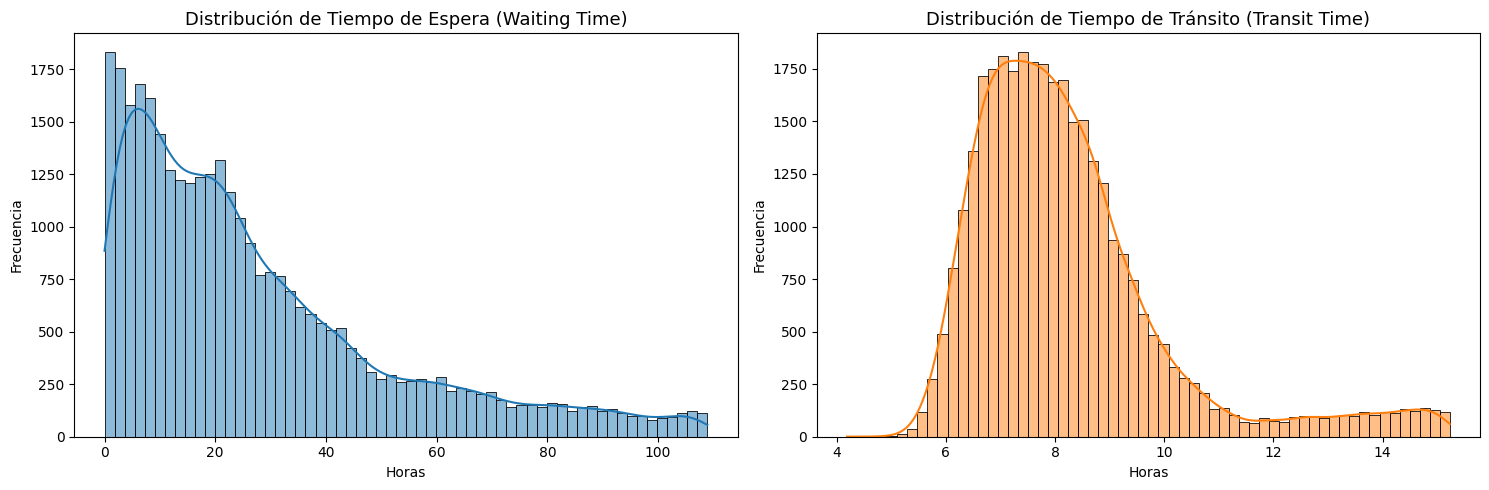

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. HISTOGRAMAS DE DISTRIBUCIÓN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para waiting_time
sns.histplot(df['waiting_time'], bins=60, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribución de Tiempo de Espera (Waiting Time)', fontsize=13)
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Frecuencia')

# Histograma para transit_time
sns.histplot(df['transit_time'], bins=60, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Distribución de Tiempo de Tránsito (Transit Time)', fontsize=13)
axes[1].set_xlabel('Horas')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


El tiempo de espera muestra una distribución sesgada a la derecha. Muchos barcos esperan poco, pero algunos esperan muchísimo.


Mientras que el tiempo de tránsito tiene una distribución más normal.
La mayoría de los tránsitos se concentran entre 7 y 9 horas.


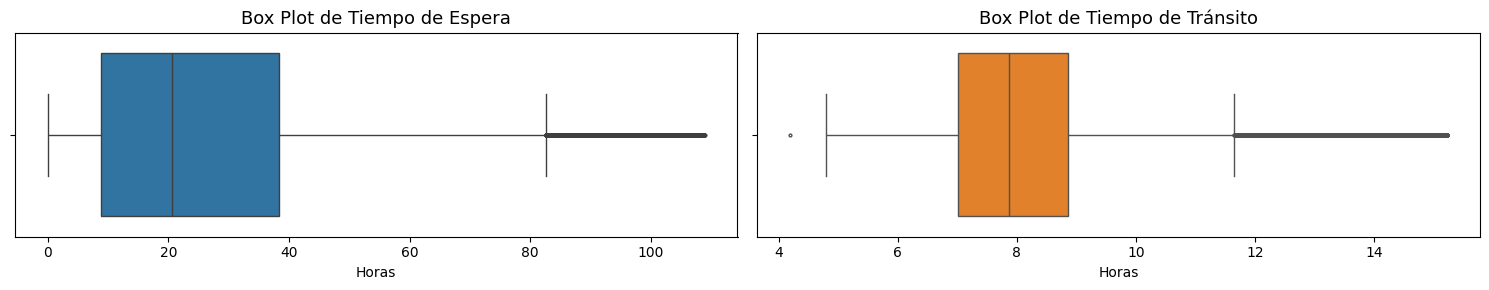

In [ ]:
# ==========================================
# 2. DIAGRAMAS DE CAJA (BOX PLOTS)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot para waiting_time
sns.boxplot(x=df['waiting_time'], ax=axes[0], color='#1f77b4', fliersize=2)
axes[0].set_title('Box Plot de Tiempo de Espera', fontsize=13)
axes[0].set_xlabel('Horas')

# Boxplot para transit_time
sns.boxplot(x=df['transit_time'], ax=axes[1], color='#ff7f0e', fliersize=2)
axes[1].set_title('Box Plot de Tiempo de Tránsito', fontsize=13)
axes[1].set_xlabel('Horas')

plt.tight_layout()
plt.show()

Tiempo de espera muestra alta dispersión y aún se ve presencia de valores extremos (hasta más de 100 horas).


Tiempo de tránsito está más concentrado, con menor variabilidad.


/tmp/ipykernel_36188/446763294.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='waiting_time', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_36188/446763294.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='transit_time', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_36188/446763294.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='waiting_time', ax=axes[1, 0], palette='Pastel1')
/tmp/ipykernel_36188/446763294.py

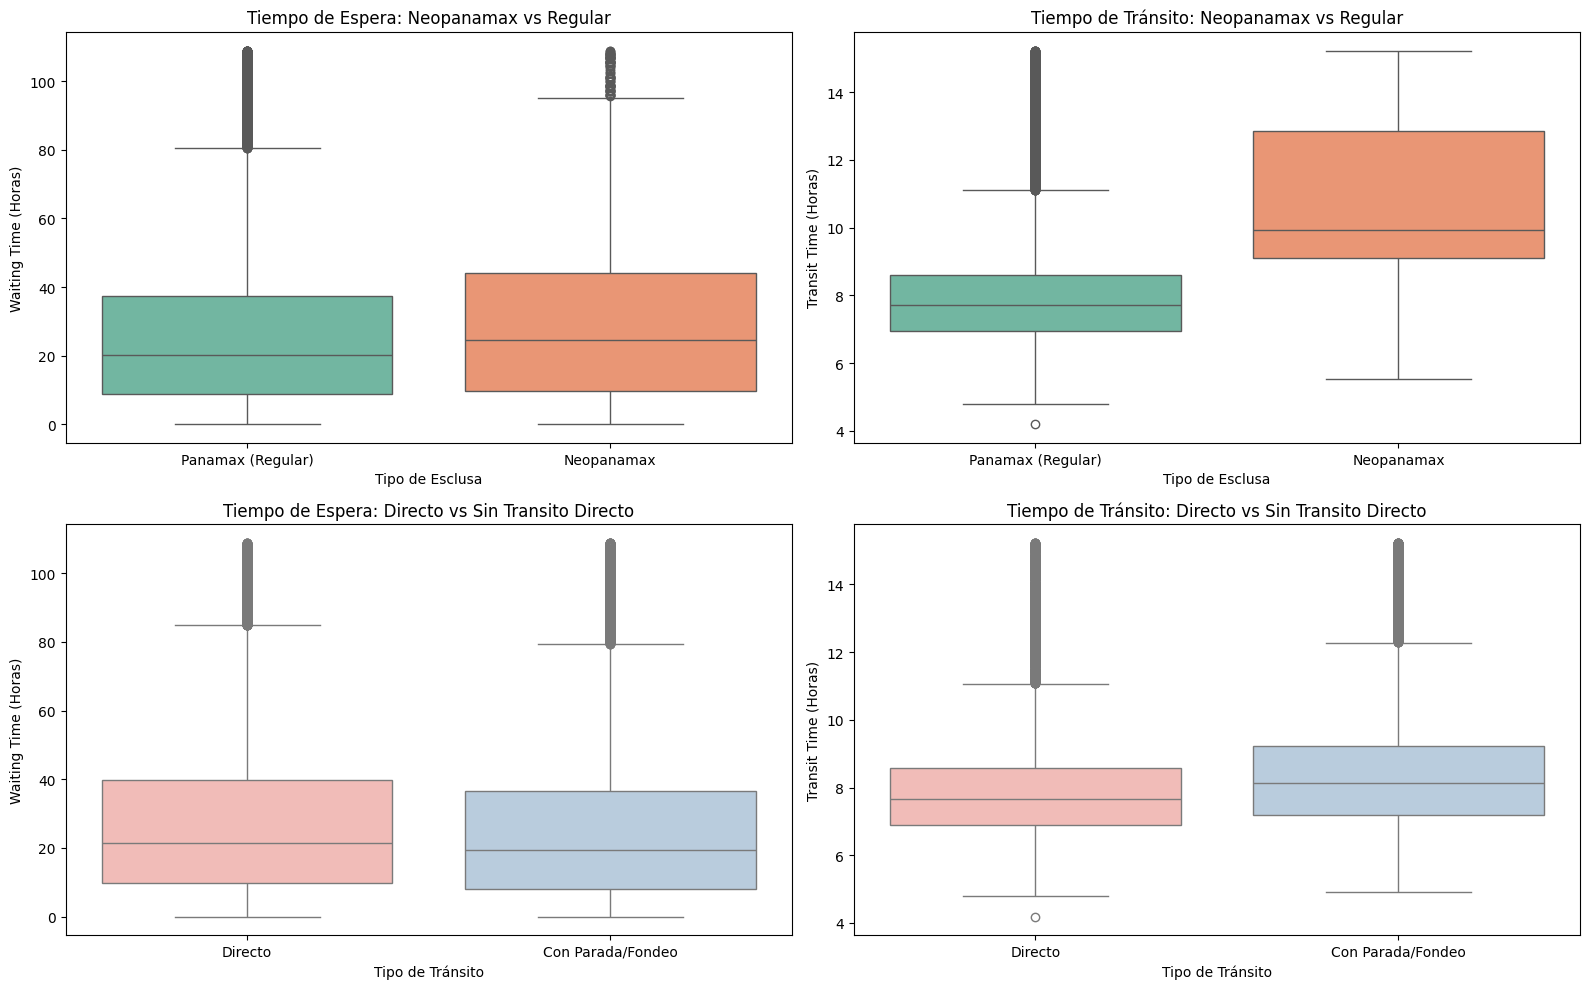

In [ ]:
# Creamos una copia para no alterar el original y ponerle etiquetas legibles a los gráficos
plot_data = df.copy()

# Mapeamos los valores binarios a texto explicativo (asumiendo 1=Sí, 0=No/Regular)
plot_data['Tipo de Esclusa'] = plot_data['neo_transit'].map({1: 'Neopanamax', 0: 'Panamax (Regular)'})
plot_data['Tipo de Tránsito'] = plot_data['direct_transit'].map({1: 'Directo', 0: 'Con Parada'})

# =========================================================
# 1. Matriz de Boxplots (Impacto individual)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fila 1: Impacto de las Esclusas (neo_transit)
sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='waiting_time', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Tiempo de Espera: Neopanamax vs Regular', fontsize=12)
axes[0, 0].set_ylabel('Waiting Time (Horas)')

sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='transit_time', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tiempo de Tránsito: Neopanamax vs Regular', fontsize=12)
axes[0, 1].set_ylabel('Transit Time (Horas)')

# Fila 2: Impacto del Tránsito Directo (direct_transit)
sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='waiting_time', ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_title('Tiempo de Espera: Directo vs Sin Transito Directo', fontsize=12)
axes[1, 0].set_ylabel('Waiting Time (Horas)')

sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='transit_time', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Tiempo de Tránsito: Directo vs Sin Transito Directo', fontsize=12)
axes[1, 1].set_ylabel('Transit Time (Horas)')

plt.tight_layout()
plt.show()


Comparando los tiempos de transito y de espera de los buques Panamax contra los Neopanamax notamos que los buques Neopanamax son más exigentes operativamente por lo que tardan más en transitar y además, tienden a experimentar mayores tiempos de espera, lo que refleja mayor complejidad en su gestión dentro del canal.


Al comparar los tiempos de espera y de tránsito de buques con transito directo contra los que hacen parada en los puertos, notamos que no hay una diferencia marcada entre ambos. Las medianas son similares, aunque el tránsito directo muestra un tiempo de espera ligeramente superior, y un tiempo de transito ligeramente inferior.





#### **Tiempo de Espera y Transito por Vessel Type**

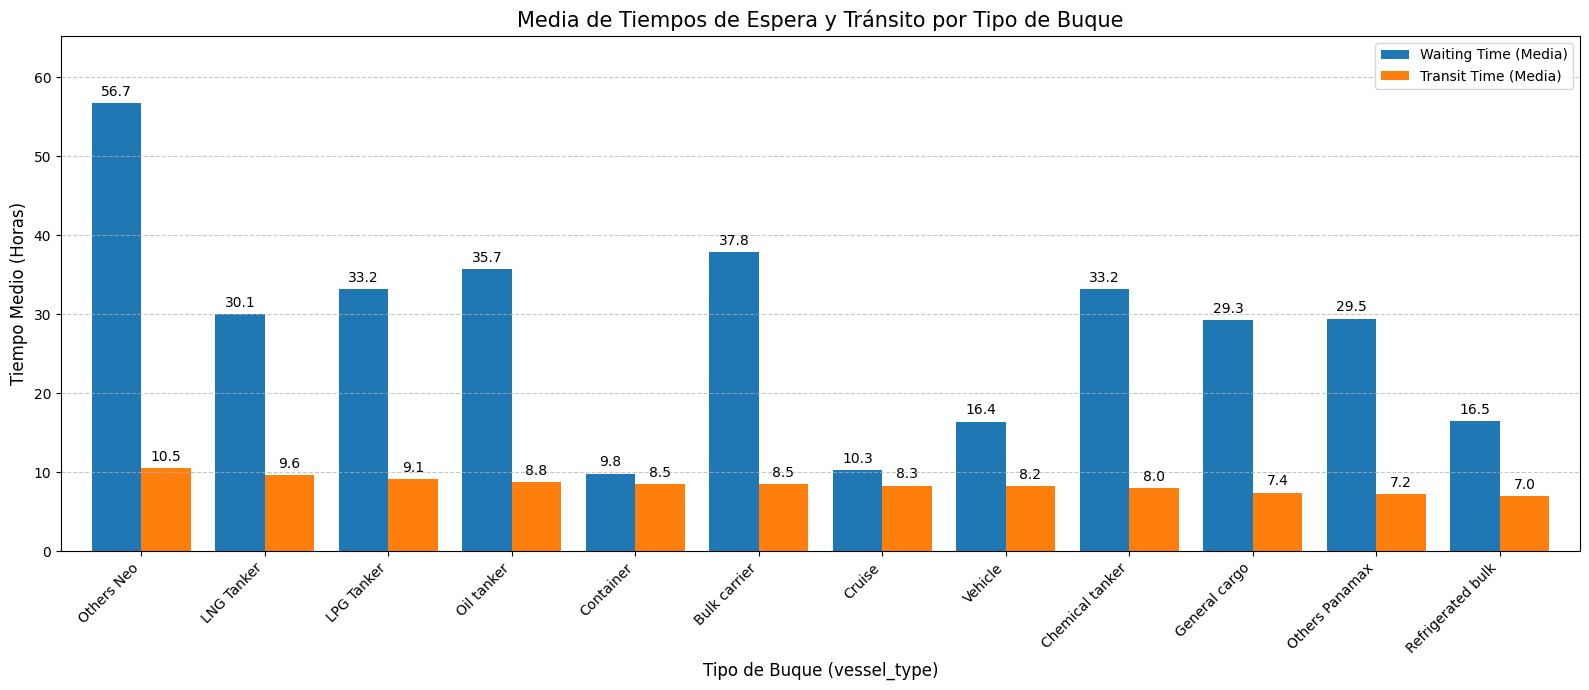

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupar por 'vessel_type' y obtener la media
avg_times = df.groupby('vessel_type')[['waiting_time', 'transit_time']].mean()

# 2. Ordenar de mayor a menor según el transit_time
avg_times = avg_times.sort_values(by='transit_time', ascending=False)

# 3. Crear el gráfico de barras
ax = avg_times.plot(kind='bar', figsize=(16, 7), width=0.8, color=['#1f77b4', '#ff7f0e'])

# 4. Configurar detalles estéticos
plt.title('Media de Tiempos de Espera y Tránsito por Tipo de Buque', fontsize=15)
plt.xlabel('Tipo de Buque (vessel_type)', fontsize=12)
plt.ylabel('Tiempo Medio (Horas)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Waiting Time (Media)', 'Transit Time (Media)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==========================================
# 5. AGREGAR ETIQUETAS A LAS BARRAS
# ==========================================
for container in ax.containers:
    # fmt='%.1f' formatea a 1 decimal (ej. 10.5). Usa '%.0f' si prefieres enteros sin decimales.
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3, fontsize=10)

# Expandir un 15% el límite superior del eje Y para que los textos no choquen con el techo
plt.ylim(0, avg_times.values.max() * 1.15)

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()

Los tiempos de tránsito son bastante parecidos entre buques, pero el tiempo de espera sí cambia mucho.

Los cruceros, contenedores, cargas refrigeradas y vehículos esperan poco, mientras que bulk carriers, tankers y “others” esperan bastante más.

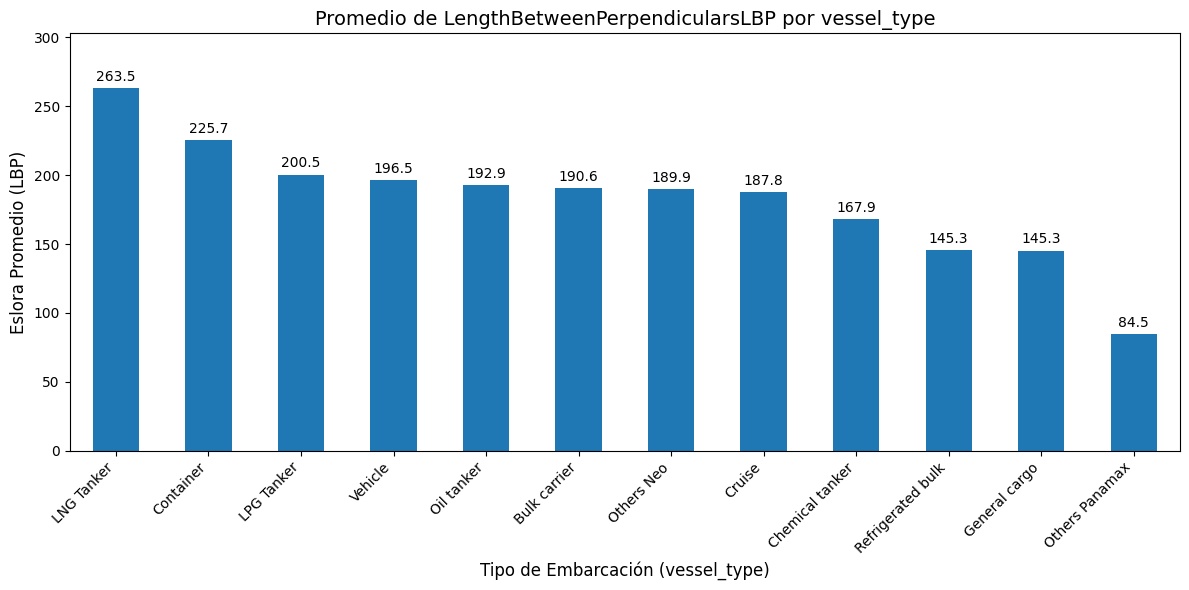

,Promedio_LBP
vessel_type,
LNG Tanker,263.488036
Container,225.716417
LPG Tanker,200.497689
Vehicle,196.487252
Oil tanker,192.878278
Bulk carrier,190.637976
Others Neo,189.942000
Cruise,187.771545
Chemical tanker,167.868210


In [ ]:
import matplotlib.pyplot as plt

# Calcular el promedio de eslora (Length) por tipo de embarcación y ordenarlo
avg_length = df.groupby('vessel_type')['LengthBetweenPerpendicularsLBP'].mean().sort_values(ascending=False)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))
avg_length.plot(kind='bar', ax=ax, color='#1f77b4')

# Añadir las etiquetas de datos a cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

# Ajustar el límite 'y' para que las etiquetas no se corten
plt.ylim(0, avg_length.max() * 1.15)

# Configurar títulos y etiquetas
plt.title('Promedio de LengthBetweenPerpendicularsLBP por vessel_type', fontsize=14)
plt.xlabel('Tipo de Embarcación (vessel_type)', fontsize=12)
plt.ylabel('Eslora Promedio (LBP)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Mostrar la tabla de valores exactos
display(avg_length.to_frame(name='Promedio_LBP'))

#### **Mapa de Correlación**

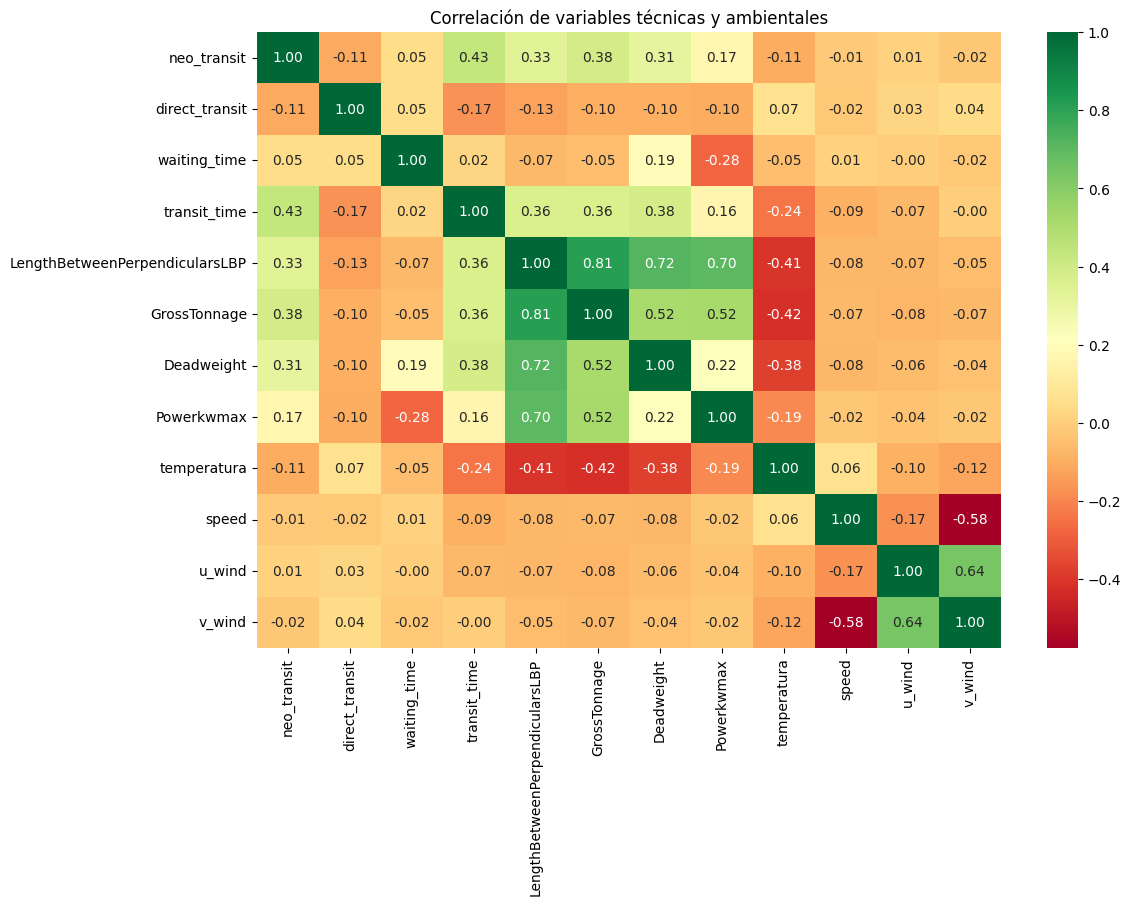

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de Correlación

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlación de variables técnicas y ambientales")
plt.show()

* El tamaño del buque es lo que más influye en el tiempo de tránsito.

* El clima y el viento casi no afectan, y el tiempo de espera no muestra relación clara con nada.

* Las variables de tamaño (Length, GrossTonnage y Deadweight) están fuertemente relacionadas entre sí, o sea, buques más largos tienden a ser más pesados y con mayor capacidad.

* También hay relación alta entre los componentes del viento (u_wind y v_wind), lo que indica que describen el mismo fenómeno desde distintas direcciones.

#### **Analisis de Estacionalidad Tiempo de Transito y Tiempo de Espera**

Estacionalidad para el Tiempo de Tránsito

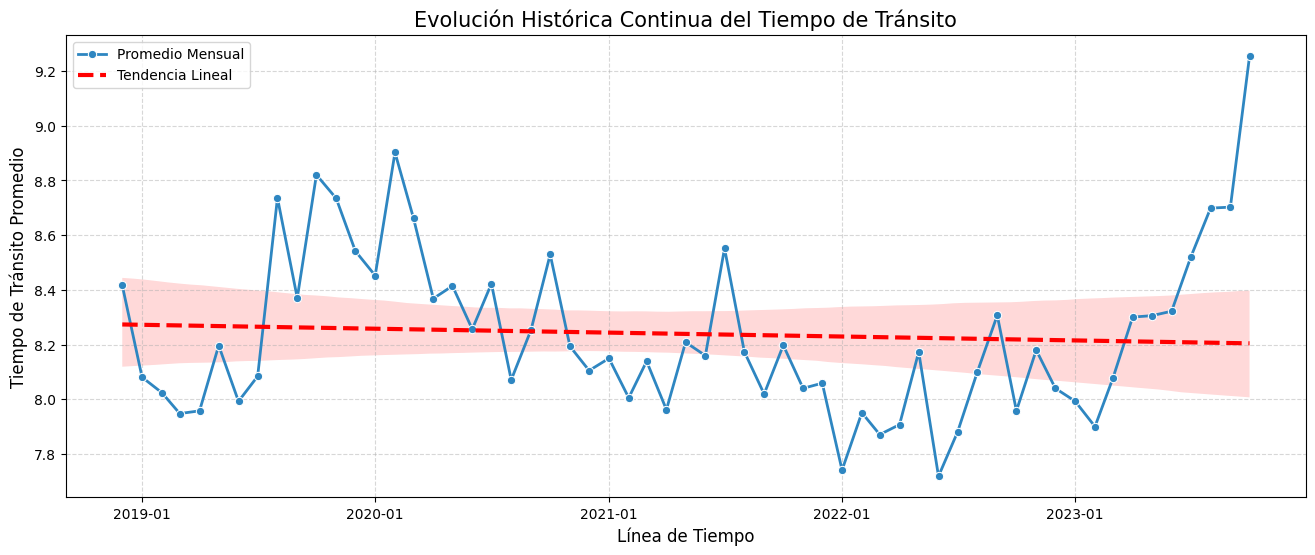

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Aseguramos que el periodo sea datetime y ordenamos
df_trend = df.groupby(df['time_anchoring_in'].dt.to_period('M'))['transit_time'].mean().reset_index()
df_trend['periodo'] = df_trend['time_anchoring_in'].dt.to_timestamp()

plt.figure(figsize=(16, 6))

# 2. Graficamos los datos reales
sns.lineplot(data=df_trend, x='periodo', y='transit_time',
             marker='o', color='#2E86C1', linewidth=2, label='Promedio Mensual')

# 3. TRUCO: Convertimos las fechas a números que regplot entienda en la misma escala
x_numeric = mdates.date2num(df_trend['periodo'])

sns.regplot(x=x_numeric,
            y=df_trend['transit_time'].values,
            scatter=False,
            color='red',
            line_kws={'linestyle': '--', 'linewidth': 3},
            label='Tendencia Lineal')

# 4. Formateo del eje X para que no se rompa
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title('Evolución Histórica Continua del Tiempo de Tránsito', fontsize=15)
plt.xlabel('Línea de Tiempo', fontsize=12)
plt.ylabel('Tiempo de Tránsito Promedio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

El tiempo de tránsito se ha mantenido bastante estable a lo largo de los años, con pequeñas fluctuaciones mes a mes. La tendencia general es ligeramente a la baja.

Estacionalidad para el Tiempo de Espera

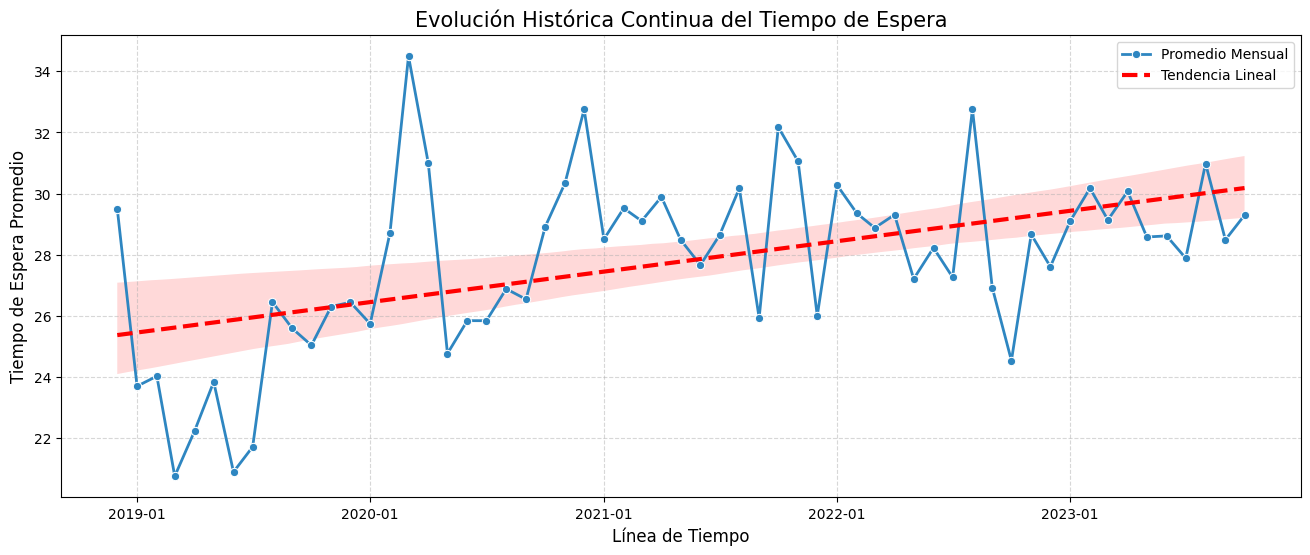

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Aseguramos que el periodo sea datetime y ordenamos
df_trend = df.groupby(df['time_anchoring_in'].dt.to_period('M'))['waiting_time'].mean().reset_index()
df_trend['periodo'] = df_trend['time_anchoring_in'].dt.to_timestamp()

plt.figure(figsize=(16, 6))

# 2. Graficamos los datos reales
sns.lineplot(data=df_trend, x='periodo', y='waiting_time',
             marker='o', color='#2E86C1', linewidth=2, label='Promedio Mensual')

# 3. TRUCO: Convertimos las fechas a números que regplot entienda en la misma escala
x_numeric = mdates.date2num(df_trend['periodo'])

sns.regplot(x=x_numeric,
            y=df_trend['waiting_time'].values,
            scatter=False,
            color='red',
            line_kws={'linestyle': '--', 'linewidth': 3},
            label='Tendencia Lineal')

# 4. Formateo del eje X para que no se rompa
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title('Evolución Histórica Continua del Tiempo de Espera', fontsize=15)
plt.xlabel('Línea de Tiempo', fontsize=12)
plt.ylabel('Tiempo de Espera Promedio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

El tiempo de espera muestra una tendencia al alza con los años.
Aunque hay bastante variabilidad mes a mes, en general cada vez se espera más, lo que sugiere mayor congestión o presión sobre la capacidad del canal.

#### **Cantidad de Barcos que Tránsitan de Forma Anual-Mensual-Diaria**



In [ ]:
import pandas as pd

# Aseguramos que las variables de tiempo existan
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month
df['fecha'] = df['time'].dt.date

# 1. Agrupación por Año
stats_anio = df.groupby('anio').agg(
    cantidad_barcos=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# 2. Agrupación por Mes (Estacionalidad histórica)
stats_mes = df.groupby('mes').agg(
    cantidad_barcos_total=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# 3. Agrupación Diaria (Para ver la carga operativa real)
stats_dia = df.groupby('fecha').agg(
    barcos_por_dia=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# Calcular la media de barcos por día (general)
media_barcos_por_dia_general = stats_dia['barcos_por_dia'].mean()
print(f"Media de barcos por día (general): {media_barcos_por_dia_general:.2f}")

# Calculate average daily ships per year
stats_dia['anio'] = pd.to_datetime(stats_dia['fecha']).dt.year
avg_daily_ships_per_year = stats_dia.groupby('anio')['barcos_por_dia'].mean().reset_index()
avg_daily_ships_per_year.rename(columns={'barcos_por_dia': 'Media Barcos por Día'}, inplace=True)

# Calculate average monthly ships per year
monthly_ships_per_year = df.groupby(['anio', 'mes'])['imo'].count().reset_index()
avg_monthly_ships_per_year = monthly_ships_per_year.groupby('anio')['imo'].mean().reset_index()
avg_monthly_ships_per_year.rename(columns={'imo': 'Media Barcos por Mes'}, inplace=True)

# Resumen ejecutivo por año (sin incertidumbres ni % Prioritarios)
resumen_ejecutivo = df.groupby('anio').agg({
    'imo': 'count',
    'transit_time': 'mean',
    'waiting_time': 'mean'
}).reset_index()

# Merge the new metrics
resumen_ejecutivo = pd.merge(resumen_ejecutivo, avg_daily_ships_per_year, on='anio', how='left')
resumen_ejecutivo = pd.merge(resumen_ejecutivo, avg_monthly_ships_per_year, on='anio', how='left')

# Renombrar columnas para claridad
resumen_ejecutivo.columns = [
    'Año', 'Total Barcos', 'Tránsito Medio (h)',
    'Espera Media (h)', 'Media Barcos por Día', 'Media Barcos por Mes'
]

resumen_ejecutivo.set_index('Año', inplace=True)


Media de barcos por día (general): 18.83


In [ ]:
resumen_ejecutivo_reordenado = resumen_ejecutivo[[
    'Total Barcos',
    'Media Barcos por Mes',
    'Media Barcos por Día',
    'Espera Media (h)',
    'Tránsito Medio (h)'
]].copy()

resumen_ejecutivo_reordenado.rename(columns={
    'Media Barcos por Mes': 'Media Mensual',
    'Media Barcos por Día': 'Media por Día',
    'Espera Media (h)': 'Tiempo Medio Espera',
    'Tránsito Medio (h)': 'Tiempo Transito Medio'
}, inplace=True)

display(resumen_ejecutivo_reordenado)

,Total Barcos,Media Mensual,Media por Día,Tiempo Medio Espera,Tiempo Transito Medio
Año,,,,,
2019,7758,646.500000,21.254795,23.842425,8.294248
2020,7102,591.833333,19.404372,28.517361,8.385126
2021,6965,580.416667,19.293629,29.066268,8.131781
2022,6135,511.250000,16.854396,28.248655,7.986446
2023,5159,515.900000,17.026403,29.426504,8.368806


La cantidad de barcos viene bajando cada año, sobre todo desde 2019 hasta 2023.

Aun con menos tráfico, el tiempo de espera aumenta, pasando de 23.8 a 29.4. Hay más demora dentro del sistema.

El tiempo de tránsito se mantiene bastante estable, incluso baja en 2022 y luego sube un poco en 2023.

## **MODELO PREDICTIVO**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

# 1. ORDENAMIENTO CRONOLÓGICO (Fundamental para Series de Tiempo)
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 4. SELECCIÓN DE CARACTERÍSTICAS (X) Y OBJETIVOS (y)
features = [
    'vessel_type', 'transit_bound', 'neo_transit',
    'GrossTonnage', 'MainEngineType','hora_sin', 'hora_cos', 'mes'#,
    #'LengthBetweenPerpendicularsLBP','Deadweight','Powerkwmax'
    #'ShiptypeLevel_group'
]

X = df[features].copy()
y = df[['transit_time', 'waiting_time']] # Multi-output target

# 5. ENCODING DE CATEGORÍAS (Convertimos texto a números procesables) usando LabelEncoder
le = LabelEncoder()
for col in ['vessel_type', 'transit_bound', 'MainEngineType']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col])

# 6. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"--- Dataset Final Preparado ---")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Variables finales: {X_train.columns.tolist()}")

--- Dataset Final Preparado ---
Dimensiones de X_train: (26495, 8)
Variables finales: ['vessel_type', 'transit_bound', 'neo_transit', 'GrossTonnage', 'MainEngineType', 'hora_sin', 'hora_cos', 'mes']


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Instanciamos el modelo base (Random Forest)
# Usamos parámetros equilibrados para evitar el sobreajuste (overfitting)
rf_base = RandomForestRegressor(
    n_estimators=1000,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

# 2. Envolvemos en MultiOutputRegressor
# Esto entrenará internamente un Random Forest para Tránsito y otro para Espera
model = MultiOutputRegressor(rf_base)

# 3. ENTRENAMIENTO
print("Entrenando... (esto puede tardar unos minutos)")
model.fit(X_train, y_train)

# 4. PREDICCIÓN
y_pred = model.predict(X_test)

# Convertimos a DataFrame para facilitar la comparación
y_pred_df = pd.DataFrame(y_pred, columns=['pred_transit', 'pred_waiting'], index=y_test.index)

Entrenando... (esto puede tardar unos minutos)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Cálculo de errores
mae_transit = mean_absolute_error(y_test['transit_time'], y_pred_df['pred_transit'])
mae_waiting = mean_absolute_error(y_test['waiting_time'], y_pred_df['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y_test['transit_time'], y_pred_df['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y_test['waiting_time'], y_pred_df['pred_waiting']))

r2_transit = r2_score(y_test['transit_time'], y_pred_df['pred_transit'])
r2_waiting = r2_score(y_test['waiting_time'], y_pred_df['pred_waiting'])

print(f"\n--- RESULTADOS ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")

# Comparativa rápida: Real vs Predicho
comparativa = pd.concat([y_test.head(10), y_pred_df.head(10)], axis=1)
print("\nPrimeras 10 predicciones vs Realidad:")
print(comparativa)


--- RESULTADOS ---
Error Medio Absoluto en Tránsito (MAE): 0.92 horas (55 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.37 horas (82 minutos)
R2 en Tránsito: 0.45

Error Medio Absoluto en Espera (MAE): 15.57 horas (934 minutos)
Error Cuadrático Medio en Espera (RMSE): 21.84 horas (1311 minutos)
R2 en Espera: 0.25

Primeras 10 predicciones vs Realidad:
       transit_time  waiting_time  pred_transit  pred_waiting
26495      8.400278     22.666667      8.645476     27.330888
26496      9.217500     83.166667      8.456249     50.277018
26497      9.275556     15.833333      8.647245     30.693591
26498      7.966667      2.000000      7.561520     14.562003
26499      7.925278     32.166667      7.503266     20.276986
26500      7.060833      4.833333      6.671629     14.552884
26501      7.104167      7.333333      7.266499     14.141539
26502      7.971667     19.000000      6.968384     27.477766
26503      7.035556     25.000000      7.146129     13.135294
26504      6.9916